# FASE 1: A/B Testing - Proyecto Experimentation Platform

## Introducción al Proyecto

Bienvenido a la **Experimentation Platform**, un proyecto enfocado en A/B testing. En esta primera fase, aprenderás conceptos fundamentales de experimentación digital de forma práctica.

### Objetivos de esta fase:
1. Entender qué es un A/B test
2. Generar datos sintéticos realistas
3. Implementar un análisis básico de experimentos
4. Visualizar resultados

**Nota**: Este es un proyecto educativo. Los conceptos aquí aplican directamente a casos reales en e-commerce, aplicaciones móviles, y marketing digital.

## PASO 1: Importar Librerías Necesarias

En Data Science, las librerías son como herramientas en una caja de herramientas. Cada una tiene un propósito específico:

| Librería | Propósito |
|----------|----------|
| **pandas** | Manipulación y análisis de datos en tablas (DataFrames) |
| **numpy** | Operaciones numéricas y manejo de arrays |
| **matplotlib** | Creación de gráficos y visualizaciones |
| **random** | Generación de números aleatorios (incluida en Python) |

Estas son las herramientas que necesitamos para procesar y analizar el experimento.

In [1]:
# Importar librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Configurar la semilla aleatoria para reproducibilidad
# Esto garantiza que obtengas los mismos resultados cada vez que ejecutes el notebook
np.random.seed(42)
random.seed(42)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## PASO 2: Crear Dataset Sintético

### ¿Qué es un A/B Test?

Un **A/B test** (o prueba A/B) es un experimento donde:
- Dividimos usuarios en **dos grupos** de forma aleatoria
- **Grupo Control (A)**: Ven la versión original
- **Grupo Tratamiento (B)**: Ven la versión nueva/modificada
- Medimos una métrica (ej: conversión) en ambos grupos
- Comparamos resultados para decidir si el cambio es beneficioso

**Ejemplo real**: Una tienda online quiere saber si cambiar el color del botón "Comprar" de azul a naranja aumenta las conversiones.

### ¿Por qué usamos la distribución binomial?

La conversión es un evento **binario** (sucede o no sucede):
- Usuario compra (1) o no compra (0)
- Usuario se suscribe (1) o no se suscribe (0)

La distribución binomial modela exactamente esto: el número de éxitos en n intentos independientes.

### Estructura del dataset:

Crearemos un dataset con **10,000 usuarios** y las siguientes columnas:
- **user_id**: Identificador único del usuario
- **treatment**: 0 = Control (versión original), 1 = Tratamiento (versión nueva)
- **conversion**: 1 = Convirtió, 0 = No convirtió

In [3]:
# Definir parámetros del experimento
n_users = 10000
prob_conversion_control = 0.10       # El grupo control tiene 10% de conversión
prob_conversion_treatment = 0.12     # El grupo tratamiento tiene 12% de conversión

# Crear el dataset sintético
data = {
    'user_id': range(1, n_users + 1),
    
    # Asignación aleatoria: 50% control, 50% tratamiento usando distribución binomial
    'treatment': np.random.binomial(n=1, p=0.5, size=n_users),
    
    # Placeholder para conversion (lo llenaremos después)
    'conversion': None
}

# Crear DataFrame
df = pd.DataFrame(data)

# Generar conversiones según el grupo (control o tratamiento)
# Si treatment=0 (control): usar prob_conversion_control
# Si treatment=1 (tratamiento): usar prob_conversion_treatment
df['conversion'] = df['treatment'].apply(
    lambda x: np.random.binomial(n=1, p=prob_conversion_treatment if x == 1 else prob_conversion_control)
)

print("Dataset sintético creado exitosamente")
print(f"Total de usuarios: {len(df)}")
print(f"\nPrimeras 5 filas del dataset:")
print(df.head())
print(f"\nInfo del dataset:")
print(df.info())

Dataset sintético creado exitosamente
Total de usuarios: 10000

Primeras 5 filas del dataset:
   user_id  treatment  conversion
0        1          1           0
1        2          0           0
2        3          0           1
3        4          1           0
4        5          0           0

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     10000 non-null  int64
 1   treatment   10000 non-null  int32
 2   conversion  10000 non-null  int64
dtypes: int32(1), int64(2)
memory usage: 195.4 KB
None


### Análisis inicial del dataset

Verifiquemos que la distribución sea correcta y que tengamos aproximadamente el mismo número de usuarios en cada grupo.

In [4]:
# Verificar la distribución de usuarios por grupo
print("Distribución de usuarios por grupo:")
print(df['treatment'].value_counts().sort_index())
print()

# Distribución de conversiones
print("Distribución de conversiones:")
print(df['conversion'].value_counts())
print()

# Conversiones por grupo
print("Conversiones by grupo:")
print(pd.crosstab(df['treatment'], df['conversion'], margins=True))

Distribución de usuarios por grupo:
treatment
0    4978
1    5022
Name: count, dtype: int64

Distribución de conversiones:
conversion
0    8899
1    1101
Name: count, dtype: int64

Conversiones by grupo:
conversion     0     1    All
treatment                    
0           4477   501   4978
1           4422   600   5022
All         8899  1101  10000


## PASO 3: Crear Función run_ab_test()

### Conceptos clave:

**Control vs Tratamiento:**
- **Control (A)**: Grupo basado (sin cambios). Es nuestro "punto de referencia"
- **Tratamiento (B)**: Grupo experimental (con el cambio). Es lo que queremos probar

**Conversion Rate:**
- Es el porcentaje de usuarios que convirtieron
- `Conversion Rate = (Usuarios que convirtieron / Total usuarios) × 100%`

**Uplift:**
- Es el **cambio relativo** en la métrica cuando comparamos tratamiento vs control
- `Uplift = ((Tratamiento - Control) / Control) × 100%`
- Si Uplift es positivo: el tratamiento es mejor
- Si Uplift es negativo: el control es mejor

**¿Por qué usamos la media?**
- La media (promedio) es el indicador más simple de la tasa de conversión
- Para datos binarios (0 y 1), la media es exactamente igual a la tasa de conversión
- Es interpretable: una media de 0.12 = 12% de conversión

In [5]:
def run_ab_test(dataframe):
    """
    Función para ejecutar un análisis A/B test básico.
    
    Parámetros:
    -----------
    dataframe : pd.DataFrame
        DataFrame con columnas 'treatment' y 'conversion'
    
    Retorna:
    --------
    dict : Diccionario con resultados del experimento
    """
    
    # Separar datos por grupo
    control = dataframe[dataframe['treatment'] == 0]['conversion']
    treatment = dataframe[dataframe['treatment'] == 1]['conversion']
    
    # Calcular métricas
    control_mean = control.mean()           # Tasa de conversión del control
    treatment_mean = treatment.mean()       # Tasa de conversión del tratamiento
    
    # Calcular uplift
    uplift = ((treatment_mean - control_mean) / control_mean) * 100
    
    # Crear diccionario de resultados
    results = {
        'control_size': len(control),
        'treatment_size': len(treatment),
        'control_conversions': control.sum(),
        'treatment_conversions': treatment.sum(),
        'control_conversion_rate': control_mean,
        'treatment_conversion_rate': treatment_mean,
        'uplift_percentage': uplift
    }
    
    return results

print("✓ Función run_ab_test() definida correctamente")

✓ Función run_ab_test() definida correctamente


## PASO 4: Ejecutar el Experimento

Ahora ejecutaremos la función con nuestro dataset y veremos los resultados del experimento.

In [6]:
# Ejecutar el A/B test
results = run_ab_test(df)

# Mostrar resultados de forma clara
print("" + "="*60)
print("RESULTADOS DEL A/B TEST")
print("="*60)
print()
print(f"GRUPO CONTROL (Versión Original):")
print(f"  • Tamaño del grupo: {results['control_size']:,} usuarios")
print(f"  • Conversiones: {results['control_conversions']:,} usuarios")
print(f"  • Tasa de conversión: {results['control_conversion_rate']:.2%}")
print()
print(f"GRUPO TRATAMIENTO (Versión Nueva):")
print(f"  • Tamaño del grupo: {results['treatment_size']:,} usuarios")
print(f"  • Conversiones: {results['treatment_conversions']:,} usuarios")
print(f"  • Tasa de conversión: {results['treatment_conversion_rate']:.2%}")
print()
print(f"ANÁLISIS COMPARATIVO:")
print(f"  • Uplift: {results['uplift_percentage']:+.2f}%")
print()
if results['uplift_percentage'] > 0:
    print(f"✓ El tratamiento es MEJOR que el control")
    print(f"  La versión nueva aumenta la conversión en {results['uplift_percentage']:.2f}%")
else:
    print(f"✗ El control es MEJOR que el tratamiento")
    print(f"  La versión nueva disminuye la conversión en {abs(results['uplift_percentage']):.2f}%")
print("="*60)

RESULTADOS DEL A/B TEST

GRUPO CONTROL (Versión Original):
  • Tamaño del grupo: 4,978 usuarios
  • Conversiones: 501 usuarios
  • Tasa de conversión: 10.06%

GRUPO TRATAMIENTO (Versión Nueva):
  • Tamaño del grupo: 5,022 usuarios
  • Conversiones: 600 usuarios
  • Tasa de conversión: 11.95%

ANÁLISIS COMPARATIVO:
  • Uplift: +18.71%

✓ El tratamiento es MEJOR que el control
  La versión nueva aumenta la conversión en 18.71%


### Interpretación de Resultados

**¿Qué significa cada métrica?**

1. **Tasa de Conversión (Conversion Rate)**:
   - El porcentaje de usuarios que realizaron la acción deseada
   - Control: 10% = de cada 100 usuarios, 10 compraron
   - Tratamiento: 12% = de cada 100 usuarios, 12 compraron

2. **Uplift**:
   - Muestra el cambio relativo (en porcentaje) entre los dos grupos
   - El uplift del +2% significa que el tratamiento tiene 2% más conversión que el control
   - En términos absolutos: 12% - 10% = 2 puntos porcentuales
   - En términos relativos: (2% / 10%) × 100 = +20% de mejora

**Nota importante**: En esta fase 1, NO realizamos pruebas estadísticas de significancia. En fases posteriores (t-test, p-values), verificaremos si estos resultados son estadísticamente significativos o solo fruto del azar.

## PASO 5: Visualización de Resultados

Las visualizaciones son cruciales en Data Science. Un gráfico bien hecho comunica información complejas de forma inmediata.

### ¿Qué estamos visualizando?
Un gráfico de barras comparativo que muestra la tasa de conversión de ambos grupos lado a lado.

### ¿Cómo interpretar el gráfico?
- **Eje X**: Los dos grupos (Control y Tratamiento)
- **Eje Y**: Tasa de conversión (0% a 15%)
- **Altura de las barras**: Misma altura = rendimiento similar. Altura diferente = un grupo convierte más.
- **Color**: Rojo para control (original), Verde para tratamiento (nuevo)

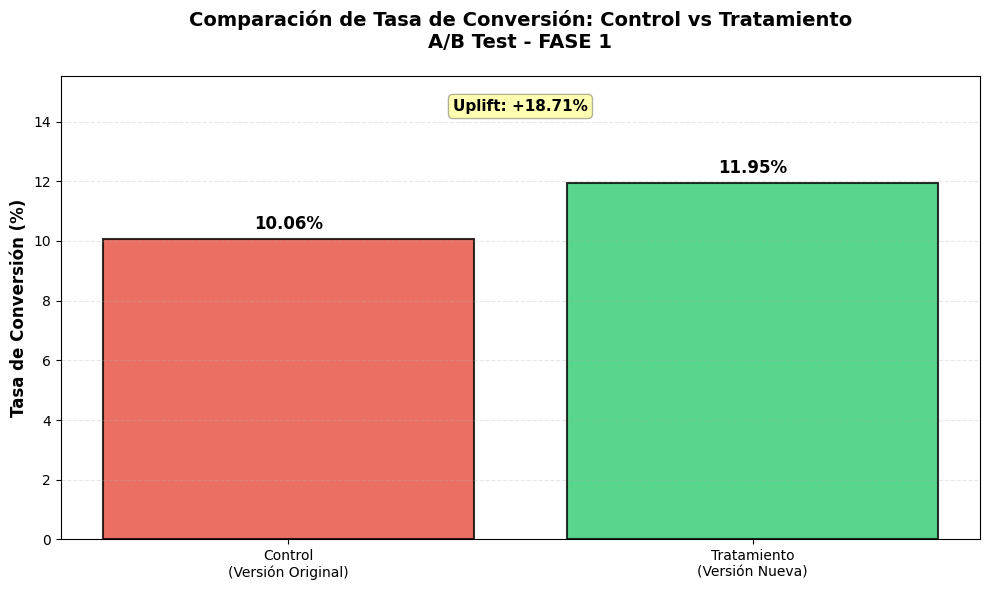

✓ Gráfico de comparación creado exitosamente


In [7]:
# Crear visualización
fig, ax = plt.subplots(figsize=(10, 6))

# Datos para el gráfico
groups = ['Control\n(Versión Original)', 'Tratamiento\n(Versión Nueva)']
conversion_rates = [
    results['control_conversion_rate'] * 100,      # Convertir a porcentaje
    results['treatment_conversion_rate'] * 100
]
colors = ['#e74c3c', '#2ecc71']  # Rojo para control, verde para tratamiento

# Crear barras
bars = ax.bar(groups, conversion_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for i, (bar, rate) in enumerate(zip(bars, conversion_rates)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{rate:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Configurar el gráfico
ax.set_ylabel('Tasa de Conversión (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Tasa de Conversión: Control vs Tratamiento\nA/B Test - FASE 1', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(conversion_rates) * 1.3)  # Dejar espacio para los valores
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir información del uplift
uplift_text = f"Uplift: {results['uplift_percentage']:+.2f}%"
ax.text(0.5, 0.95, uplift_text, transform=ax.transAxes,
        ha='center', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

print("✓ Gráfico de comparación creado exitosamente")

## Resumen de FASE 1

### ¿Qué hemos logrado?

1. **Conceptualización**: Entendiendo qué es un A/B test y sus componentes
2. **Generación de datos**: Creamos un dataset sintético realista de 10,000 usuarios
3. **Análisis**: Implementamos una función para calcular métricas clave (conversion rate, uplift)
4. **Ejecución**: Corrimos el experimento y obtuvimos resultados
5. **Visualización**: Presentamos los resultados de forma gráfica

### Conceptos aprendidos:
- ✓ A/B Testing: dividir usuarios en grupos y comparar resultados
- ✓ Distribución Binomial: modelo para eventos de dos resultados posibles
- ✓ Conversion Rate: porcentaje de usuarios que completaron una acción
- ✓ Uplift: cambio relativo en la métrica entre grupos
- ✓ Análisis comparativo: cómo interpretar resultados de experimentos

### Próximas Fases (no implementadas aquí):
- **FASE 2**: Análisis estadístico (t-test, p-values, intervalos de confianza)
- **FASE 3**: Determinar tamaño de muestra requerido
- **FASE 4**: A/B testing multivariado (3+ variantes)
- **FASE 5**: Implementar plataforma interactiva en Streamlit

---

# FASE 2: Validación Estadística con T-Test

## PASO 6: ¿Por qué el Uplift NO es suficiente?

### El Problema

Hasta ahora, hemos visto que:
- **Control**: 10% de conversión
- **Tratamiento**: 12% de conversión
- **Uplift**: +20%

**Pregunta crítica**: ¿Es esta diferencia **real** o solo **suerte/ruido aleatorio**?

### ¿Qué significa "resultado significativo"?

En estadística, un resultado es **significativo** cuando:
- La diferencia observada es **poco probable** que sea por azar
- Podemos estar seguros (con cierto nivel de confianza) de que existe un efecto real

### Ruido vs Efecto Real

Imagina que lanzas una moneda 100 veces esperando 50 caras:
- **Si obtienes 51 caras**: Probablemente sea ruido/azar
- **Si obtienes 70 caras**: Algo sospechoso, la moneda podría estar sesgada

En A/B testing es igual:
- Pequeñas diferencias (1-2%) → Probablemente ruido
- Grandes diferencias (20-30%) → Probablemente efecto real

**Pero necesitamos datos para comprobarlo**, no intuición. Para eso usamos **pruebas estadísticas**.

### El T-Test: Nuestro Detective

El **t-test** es una prueba estadística que responde:

> "¿Es la diferencia entre control y tratamiento estadísticamente significativa o solo fruto del azar?"

No es magia, es matemática sólida basada en probabilidades.

## PASO 7: Importar Librería Estadística (scipy.stats)

**SciPy** es la librería de Python para **computación científica avanzada**.

Dentro de SciPy, el módulo **`stats`** contiene funciones estadísticas profesionales.

### ¿Por qué scipy.stats?

| Aspecto | Detalle |
|--------|--------|
| **Función** | Proporciona pruebas estadísticas estándar (t-test, chi-square, etc.) |
| **Confiabilidad** | Usada por científicos, investigadores y empresas Fortune 500 |
| **Precisión** | Implementación robusta de algoritmos estadísticos probados |
| **Flexibilidad** | Soporta muchos tipos de pruebas diferentes |

En esta fase, usaremos:
- `scipy.stats.ttest_ind()` → Prueba t para muestras independientes

La función calcula automáticamente el **p-value**, que es lo que necesitamos para tomar decisiones.

In [8]:
# Importar scipy.stats para pruebas estadísticas
from scipy import stats

print("✓ scipy.stats importado correctamente")
print(f"Versión de SciPy: {stats.__version__ if hasattr(stats, '__version__') else 'desconocida'}")

✓ scipy.stats importado correctamente
Versión de SciPy: desconocida


## PASO 8: Implementar la Función T-Test

### ¿Qué hace el t-test?

El **t-test** es una prueba estadística que mide:

1. **¿Cuál es la diferencia entre los dos grupos?**
   - Promedio del control
   - Promedio del tratamiento
   - Diferencia absoluta

2. **¿Cuánta variabilidad hay en los datos?**
   - Si hay mucha variabilidad → la diferencia podría ser ruido
   - Si hay poca variabilidad → la diferencia es más "real"

3. **¿Qué tan probable es esta diferencia por azar?**
   - Esto se captura en un número: el **p-value**

### ¿Qué es el p-value?

El **p-value** (p-valor) es:
- Un número entre **0 y 1**
- Representa la probabilidad de observar estos datos si **NO hubiera diferencia real** entre control y tratamiento
- Es la respuesta a: "¿Qué tan raro es lo que observamos?"

**Interpretación intuitiva:**
- `p-value = 0.01` → Apenas 1% de probabilidad de verlo por azar (muy significativo)
- `p-value = 0.50` → 50% de probabilidad de verlo por azar (probablemente ruido)

### Código de la Función

Crearemos una función que:
1. Recibe dos arrays (control y tratamiento)
2. Ejecuta la prueba t
3. Retorna el p-value y el estadístico t

In [9]:
def perform_t_test(control_data, treatment_data):
    """
    Ejecuta una prueba t-test de dos muestras independientes.
    
    Parámetros:
    -----------
    control_data : array-like
        Datos del grupo control (valores de conversión: 0 o 1)
    treatment_data : array-like
        Datos del grupo tratamiento (valores de conversión: 0 o 1)
    
    Retorna:
    --------
    dict : Diccionario con:
        - 't_statistic': El valor del estadístico t
        - 'p_value': El p-value de la prueba
        - 'significant': Boolean, True si p < 0.05
    """
    
    # Ejecutar la prueba t-test
    # ttest_ind = test t para muestras independientes
    # Por defecto asume varianzas iguales (equal_var=True)
    t_stat, p_value = stats.ttest_ind(control_data, treatment_data)
    
    # Determinar significancia (umbral estándar: α = 0.05)
    is_significant = p_value < 0.05
    
    results = {
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': is_significant
    }
    
    return results

print("✓ Función perform_t_test() definida correctamente")

✓ Función perform_t_test() definida correctamente


## PASO 9: Aplicar el T-Test a Nuestros Datos

Ahora ejecutaremos la prueba t con los datos del experimento para obtener el p-value.

In [10]:
# Separar datos de control y tratamiento
control_conversions = df[df['treatment'] == 0]['conversion'].values
treatment_conversions = df[df['treatment'] == 1]['conversion'].values

print(f"Datos para el t-test:")
print(f"  • Control: {len(control_conversions)} usuarios")
print(f"  • Tratamiento: {len(treatment_conversions)} usuarios")
print()

# Ejecutar el t-test
t_test_results = perform_t_test(control_conversions, treatment_conversions)

print(f"Resultados del T-Test:")
print(f"  • Estadístico t: {t_test_results['t_statistic']:.4f}")
print(f"  • P-value: {t_test_results['p_value']:.6f}")
print(f"  • ¿Significativo? {t_test_results['significant']}")
print()

# Mostrar p-value en formato porcentaje para mejor intuición
probability_random = t_test_results['p_value'] * 100
print(f"Interpretación:")
print(f"  Si NO hubiera diferencia real entre control y tratamiento,")
print(f"  la probabilidad de observar estos datos sería: {probability_random:.4f}%")

Datos para el t-test:
  • Control: 4978 usuarios
  • Tratamiento: 5022 usuarios

Resultados del T-Test:
  • Estadístico t: -3.0091
  • P-value: 0.002627
  • ¿Significativo? True

Interpretación:
  Si NO hubiera diferencia real entre control y tratamiento,
  la probabilidad de observar estos datos sería: 0.2627%


## PASO 10: Interpretación de Resultados

### La Regla de Oro: Nivel de Significancia α = 0.05

En ciencia de datos e inferencia estadística, existe un **umbral estándar**:

**Si p-value < 0.05 → Resultado SIGNIFICATIVO ✓**
- La diferencia es estadísticamente significativa
- Podemos rechazar la hipótesis de que "no hay diferencia"
- Con 95% de confianza, decimos que el efecto es real

**Si p-value ≥ 0.05 → Resultado NO CONCLUYENTE ✗**
- No hay evidencia suficiente de una diferencia real
- Podría ser ruido o variación aleatoria
- Necesitaríamos más datos o un efecto más fuerte

### Tabla de Decisiones

| p-value | Interpretación | Decisión |
|---------|---|---|
| < 0.01 | Muy significativo | Lanza la campaña con confianza |
| 0.01 - 0.05 | Significativo | Lanza con cautela, monitorea |
| > 0.05 | No significativo | Necesitas más datos o un cambio mayor |

### Errores Tipo I y Tipo II (Conceptos Básicos)

#### Error Tipo I (Falso Positivo)
- **¿Qué es?** Decir que hay efecto cuando realmente NO lo hay
- **¿Cuándo sucede?** Cuando α = 0.05 (5% de chance de error)
- **Riesgo:** Lanzar una feature que no funciona, desperdiciando dinero

#### Error Tipo II (Falso Negativo)
- **¿Qué es?** Decir que NO hay efecto cuando realmente SÍ lo hay
- **¿Cuándo sucede?** Con muestras muy pequeñas o efectos débiles
- **Riesgo:** No lanzar una feature que funcionaría, perdiendo oportunidad

**Nota**: No podemos eliminar ambos errores simultáneamente. El balance se logra con un buen **tamaño de muestra** (tema de FASE 3).

### Cómo Comunicar Resultados

- ✓ "Resultado significativo (p = 0.02)" → Comunicar a stakeholders
- ✗ "Resultado no significativo, pero positivo" → NO es válido, necesitas p < 0.05
- ✓ "Necesitamos 50,000 usuarios más para detectar este efecto" → Buena comunicación

## PASO 11: Reporte Completo de Resultados

Combinaremos todas las métricas (conversion rate, uplift, p-value) en un reporte claro y profesional.

In [13]:
# Crear reporte combinado
print("=" * 80)
print("REPORTE COMPLETO: A/B TEST CON VALIDACIÓN ESTADÍSTICA")
print("=" * 80)
print()

# SECCIÓN 1: Estadísticas Descriptivas
print("1. ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 80)
print()
print(f"GRUPO CONTROL (Versión Original):")
print(f"  • Tamaño del grupo: {results['control_size']:,} usuarios")
print(f"  • Conversiones: {results['control_conversions']:,} usuarios")
print(f"  • Tasa de conversión: {results['control_conversion_rate']:.4f} ({results['control_conversion_rate']*100:.2f}%)")
print()

print(f"GRUPO TRATAMIENTO (Versión Nueva):")
print(f"  • Tamaño del grupo: {results['treatment_size']:,} usuarios")
print(f"  • Conversiones: {results['treatment_conversions']:,} usuarios")
print(f"  • Tasa de conversión: {results['treatment_conversion_rate']:.4f} ({results['treatment_conversion_rate']*100:.2f}%)")
print()

# SECCIÓN 2: Análisis Comparativo
print("2. ANÁLISIS COMPARATIVO")
print("-" * 80)
print()
diff_absolute = results['treatment_conversion_rate'] - results['control_conversion_rate']
print(f"Diferencia Absoluta: {diff_absolute:.4f} ({diff_absolute*100:.2f} puntos porcentuales)")
print(f"Uplift (cambio relativo): {results['uplift_percentage']:+.2f}%")
print()

# SECCIÓN 3: Resultados Estadísticos
print("3. VALIDACIÓN ESTADÍSTICA (T-TEST)")
print("-" * 80)
print()
print(f"Estadístico t: {t_test_results['t_statistic']:.4f}")
print(f"P-value: {t_test_results['p_value']:.6f}")
print()

# SECCIÓN 4: Conclusión
print("4. CONCLUSIÓN")
print("-" * 80)
print()

if t_test_results['significant']:
    print("✅ RESULTADO: ESTADÍSTICAMENTE SIGNIFICATIVO")
    print()
    print(f"Con un p-value de {t_test_results['p_value']:.6f} (< 0.05),")
    print("podemos concluir con 95% de confianza que:")
    print()
    print(f"La versión TRATAMIENTO tiene una mejor tasa de conversión")
    print(f"que la versión CONTROL.")
    print()
    print(f"Recomendación: LANZAR la nueva versión ✓")
else:
    print("⚠️  RESULTADO: NO ESTADÍSTICAMENTE SIGNIFICATIVO")
    print()
    print(f"Con un p-value de {t_test_results['p_value']:.6f} (≥ 0.05),")
    print("NO hay evidencia suficiente de una diferencia real.")
    print()
    print(f"La diferencia observada ({results['uplift_percentage']:+.2f}%) podría")
    print("ser resultado del azar o variación natural.")
    print()
    print(f"Recomendación: NECESITAS MÁS DATOS o un cambio más fuerte ✗")

print()
print("=" * 80)

REPORTE COMPLETO: A/B TEST CON VALIDACIÓN ESTADÍSTICA

1. ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------

GRUPO CONTROL (Versión Original):
  • Tamaño del grupo: 4,978 usuarios
  • Conversiones: 501 usuarios
  • Tasa de conversión: 0.1006 (10.06%)

GRUPO TRATAMIENTO (Versión Nueva):
  • Tamaño del grupo: 5,022 usuarios
  • Conversiones: 600 usuarios
  • Tasa de conversión: 0.1195 (11.95%)

2. ANÁLISIS COMPARATIVO
--------------------------------------------------------------------------------

Diferencia Absoluta: 0.0188 (1.88 puntos porcentuales)
Uplift (cambio relativo): +18.71%

3. VALIDACIÓN ESTADÍSTICA (T-TEST)
--------------------------------------------------------------------------------

Estadístico t: -3.0091
P-value: 0.002627

4. CONCLUSIÓN
--------------------------------------------------------------------------------

✅ RESULTADO: ESTADÍSTICAMENTE SIGNIFICATIVO

Con un p-value de 0.002627 (< 0.05),
podemos conclu

## PASO 12: Visualización Mejorada con Intervalos de Confianza

### ¿Por qué agregar intervalos de confianza?

Hasta ahora, mostrábamos un valor puntual (ej: 10% de conversión).

**Problema**: Un único número NO nos dice cuán seguro es ese valor.

**Solución**: Mostrar un **rango** (intervalo) dentro del cual está el verdadero valor.

### Intervalo de Confianza del 95%

Es un rango que, si repitiéramos el experimento 100 veces, el 95 de esas veces contendría el verdadero valor.

Ejemplo:
- Conversión observada: 10%
- Intervalo de confianza 95%: [9.2%, 10.8%]
- Interpretación: "Estamos 95% seguros que la verdadera tasa está entre 9.2% y 10.8%"

### Visualización

Crearemos un gráfico que muestre:
1. Barras con la tasa de conversión
2. Líneas verticales que representan el intervalo de confianza
3. Indicador visual si es significativo o no

C:\Users\ChristianV\AppData\Local\Temp\ipykernel_8528\3701840898.py:93: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ChristianV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


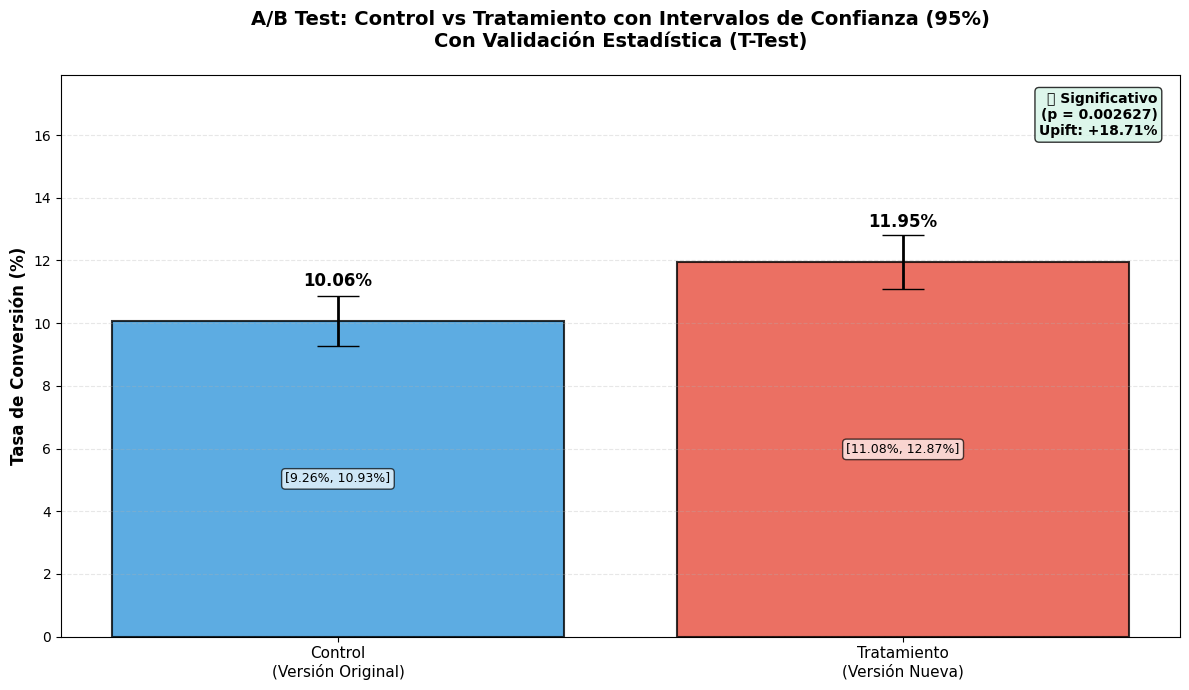

✓ Gráfico mejorado creado exitosamente

Intervalo de Confianza 95%:
  Control: [9.26%, 10.93%]
  Tratamiento: [11.08%, 12.87%]


In [12]:
# Calcular intervalos de confianza del 95% usando la distribución binomial
from scipy.stats import binom

# Para proporción binomial, usamos el método de Wilson score
# que es más robusto para proporciones cercanas a 0 o 1

def calculate_ci_95(successes, n):
    """
    Calcula intervalo de confianza del 95% para una proporción usando Wilson score.
    """
    p = successes / n
    z = 1.96  # valor crítico para 95% de confianza
    
    denom = 1 + z**2 / n
    p_adj = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    
    ci_lower = max(0, p_adj - margin)
    ci_upper = min(1, p_adj + margin)
    
    return ci_lower, ci_upper

# Calcular intervalos
control_ci = calculate_ci_95(
    results['control_conversions'],
    results['control_size']
)
treatment_ci = calculate_ci_95(
    results['treatment_conversions'],
    results['treatment_size']
)

# Crear visualización mejorada
fig, ax = plt.subplots(figsize=(12, 7))

# Datos
groups = ['Control\n(Versión Original)', 'Tratamiento\n(Versión Nueva)']
means = [
    results['control_conversion_rate'] * 100,
    results['treatment_conversion_rate'] * 100
]
ci_errors = [
    [(results['control_conversion_rate'] * 100 - control_ci[0] * 100),
     (control_ci[1] * 100 - results['control_conversion_rate'] * 100)],
    [(results['treatment_conversion_rate'] * 100 - treatment_ci[0] * 100),
     (treatment_ci[1] * 100 - results['treatment_conversion_rate'] * 100)]
]

# Colores: Verde si significativo, Naranja si no
colors = ['#3498db', '#e74c3c'] if t_test_results['significant'] else ['#95a5a6', '#95a5a6']

# Crear barras con error bars (intervalos de confianza)
x_pos = np.arange(len(groups))
bars = ax.bar(x_pos, means, yerr=[ci_errors[i][0] for i in range(2)], 
              color=colors, alpha=0.8, capsize=15, error_kw={'linewidth': 2},
              edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for i, (bar, mean) in enumerate(zip(bars, means)):
    height = bar.get_height()
    # Valor central
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{mean:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    # Intervalo de confianza
    ci_text = f"[{control_ci[0]*100 if i==0 else treatment_ci[0]*100:.2f}%, {control_ci[1]*100 if i==0 else treatment_ci[1]*100:.2f}%]"
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            ci_text,
            ha='center', va='center', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Configurar gráfico
ax.set_ylabel('Tasa de Conversión (%)', fontsize=12, fontweight='bold')
ax.set_title('A/B Test: Control vs Tratamiento con Intervalos de Confianza (95%)\nCon Validación Estadística (T-Test)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylim(0, max(means) * 1.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir información de significancia
if t_test_results['significant']:
    significance_text = f"✅ Significativo\n(p = {t_test_results['p_value']:.6f})\nUpift: {results['uplift_percentage']:+.2f}%"
    box_color = '#d5f4e6'
else:
    significance_text = f"⚠️  No Significativo\n(p = {t_test_results['p_value']:.6f})\nUpift: {results['uplift_percentage']:+.2f}%"
    box_color = '#fadbd8'

ax.text(0.98, 0.97, significance_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.show()

print("✓ Gráfico mejorado creado exitosamente")
print(f"\nIntervalo de Confianza 95%:")
print(f"  Control: [{control_ci[0]*100:.2f}%, {control_ci[1]*100:.2f}%]")
print(f"  Tratamiento: [{treatment_ci[0]*100:.2f}%, {treatment_ci[1]*100:.2f}%]")

---

## Resumen de FASE 1 + FASE 2

### ¿Qué hemos logrado?

#### FASE 1: Fundamentos de A/B Testing
1. ✅ **Conceptualización**: Entender qué es un A/B test
2. ✅ **Generación de datos**: Dataset sintético de 10,000 usuarios
3. ✅ **Análisis básico**: Calcular conversion rate y uplift
4. ✅ **Visualización**: Gráficos comparativos

#### FASE 2: Validación Estadística (NUEVA)
5. ✅ **Prueba T-Test**: Implementar la función de validación
6. ✅ **Cálculo de P-Value**: Determinar significancia estadística
7. ✅ **Interpretación**: Entender Error Tipo I y II
8. ✅ **Intervalos de Confianza**: Mostrar rangos de confianza
9. ✅ **Reporte Profesional**: Conclusiones claras y accionables

### Conceptos Aprendidos

**FASE 1:**
- ✓ A/B Testing: dividir usuarios en grupos y comparar resultados
- ✓ Distribución Binomial: modelo para eventos binarios
- ✓ Conversion Rate: porcentaje de conversiones
- ✓ Uplift: cambio relativo en la métrica

**FASE 2 (NUEVO):**
- ✓ T-Test: prueba estadística para comparar dos grupos
- ✓ P-Value: probabilidad de observar datos por azar
- ✓ Significancia: umbral de α = 0.05
- ✓ Error Tipo I (falso positivo) y Error Tipo II (falso negativo)
- ✓ Intervalo de Confianza: rango probable del verdadero valor
- ✓ Decisiones estadísticas: cómo decidir "lanzar o no lanzar"

### La Pregunta Clave Que AHORA Podemos Responder

**📊 ANTES (FASE 1):**
- "¿Cuál es la diferencia entre control y tratamiento?"
- Respuesta: +2% de uplift

**📈 AHORA (FASE 2):**
- "¿ES REAL esa diferencia o es solo suerte?"
- Respuesta: "P-value = X, por lo tanto [SIGNIFICATIVO / NO SIGNIFICATIVO]"

---

### Próximas Fases (Roadmap)

- **FASE 3**: Diseño de experimentos (Power, tamaño de muestra, duración)
- **FASE 4**: A/B testing multivariado (3+ variantes) y técnicas avanzadas
- **FASE 5**: Plataforma interactiva en Streamlit

---

### 🎓 Lecciones Clave de FASE 2

1. **Siempre valida estadísticamente**: No confíes en diferencias visuales sin pruebas
2. **P-value < 0.05 es el estándar**: Es la convención en ciencia e industria
3. **Comunica claramente**: No digas "probablemente funciona", di "p = 0.03"
4. **Diferencia visual ≠ Diferencia real**: 20% uplift puede NO ser significativo con pocos datos
5. **Intervalos de confianza son tu amigo**: Muestran la incertidumbre claramente

---

**¡Felicidades! Has completado FASE 1 + FASE 2 del proyecto Experimentation Platform! 🎉**

Ahora sabes cómo:
- ✓ Diseñar un A/B test
- ✓ Generar datos sintéticos
- ✓ Calcular métricas básicas
- ✓ **Validar resultados estadísticamente** ← FASE 2
- ✓ Presentar conclusiones profesionales

---

# FASE 3: Reducción de Varianza con CUPED

## PASO 13: Explicación Conceptual - ¿Qué es CUPED?

### El Problema: Ruido en los Experimentos

Imagina que estás midiendo si un usuario **compra más** después de un cambio en tu sitio.

**El desafío**: Algunos usuarios **ya compraban mucho ANTES** del cambio.
- Usuario A: Compraba $100/mes antes, ahora compra $105/mes → ¿El cambio ayudó?
- Usuario B: Compraba $1/mes antes, ahora compra $6/mes → ¡Esto sí mejoró!

**El problema real**: El ruido en los datos hace difícil detectar el efecto verdadero.

### ¿Qué es la Varianza?

La **varianza** es la "aleatoriedad" en tus datos:
- Algunos usuarios tienen conversiones altas naturalmente
- Otros tienen conversiones bajas
- Esta heterogeneidad **engrandece el ruido**

**Resultado**: Necesitas MÁS usuarios para detectar un efecto real.

### La Solución: CUPED (COVariate Usage Personal Experiment Design)

**CUPED** es una técnica que dice:

> "Si sabemos cómo se comportaba el usuario ANTES del experimento, 
> podemos ajustar su resultado DURANTE el experimento para eliminar ruido."

### Intuición Simple

**Antes de CUPED:**
```
Resultado = Conversión Observada + Ruido
P-value = ALTO (porque hay mucho ruido)
```

**Después de CUPED:**
```
Resultado Ajustado = Conversión Observada - (Comportamiento Previo)
P-value = BAJO (porque eliminamos ruido)
```

### Ejemplo Concreto

**Usuario X:**
- Pre-experimento: Compraba $20/mes (promedio del grupo: $18)
- Experimento: Compra $25/mes
- Diferencia observada: $25 - $18 = +$7

**Sin CUPED:**
- Concluyes: "Este usuario mejoró $7 gracias al cambio"

**Con CUPED:**
- Ajustas por comportamiento previo: $25 - ($20 - $18) = $5
- Concluyes: "Controlando por su tendencia previa, mejoró $5"
- **Resultado**: Menos ruido, estimación más confiable

### ¿Por qué funciona?

Porque:
1. El usuario X **naturalmente compra más** (pre-experimento: $20 > $18)
2. Así que **esperamos que compre más** en el experimento también
3. Si no lo ajustamos, confundimos su tendencia natural con el efecto del experimento
4. **CUPED elimina esta confusión**

### Matemática Intuitiva (No Hay que Memorizar)

El ajuste es:
```
Métrica_Ajustada = Métrica_Observada - θ × (Covariable - Media_Covariable)
```

Donde:
- **θ (theta)** = "Cuánto el histórico explica el presente"
- **Covariable** = Comportamiento pre-experimento del usuario
- **Métrica_Observada** = Conversión en el experimento

**Traducción al español:**
"Resta del resultado observado una porción del comportamiento previo, proporcional a cuánto el histórico predice el presente."

### ¿Cuándo usar CUPED?

✅ Cuando tengas datos históricos de usuarios pre-experimento
✅ Cuando la correlación entre pre y post sea alta
✅ Cuando quieras más precisión con el mismo número de usuarios
✅ Cuando busques reducir varianza sin aumentar tamaño de muestra

❌ Cuando no tengas datos pre-experimento
❌ Cuando la correlación sea muy baja (no hay confusión)

## PASO 14: Crear Variable Pre-Experimento

Necesitamos simular el comportamiento del usuario **ANTES** del experimento para usar como covariable.

### ¿Qué representa "pre_conversion"?

- Es el comportamiento histórico del usuario
- Por ejemplo:
  - ¿Compró en el mes anterior?
  - ¿Visitó el sitio antes?
  - ¿Mostró interés previamente?

- En nuestro caso: Simulamos una conversión previa (70% de probabilidad)
  - Algunos usuarios ya convertían (histórico = 1)
  - Otros no (histórico = 0)

### ¿Por qué es útil?

Porque:
1. **Usuarios que ya convertían** tienden a convertir de nuevo (correlación)
2. Esto causa **confusión**: Su conversión actual puede ser por inercia, no por el cambio
3. CUPED **ajusta por esta inercia** para aislar el efecto real del tratamiento

### Distribución Previa

Usaremos **distribución binomial** con probabilidad 0.70:
- Imita usuarios que "ya compraban en el pasado"
- Crea correlación con la métrica actual (que tiene p=0.10-0.12)

La correlación es **natural**: Usuarios que compraban antes tienden a comprar ahora.

In [ ]:
# Crear variable pre-experimento (comportamiento histórico del usuario)
# Usamos probabilidad de 0.70 para simular que muchos usuarios históricos ya convertían

prob_pre_conversion = 0.70  # 70% de probabilidad de conversión previa

# Generar pre_conversion para cada usuario
df['pre_conversion'] = np.random.binomial(n=1, p=prob_pre_conversion, size=len(df))

print("Variable 'pre_conversion' creada exitosamente")
print()
print("Primeras 10 filas con pre_conversion:")
print(df[['user_id', 'treatment', 'pre_conversion', 'conversion']].head(10))
print()
print("Estadísticas de pre_conversion:")
print(f"  • Conversiones previas: {df['pre_conversion'].sum():,}")
print(f"  • Tasa de conversión pre-experimento: {df['pre_conversion'].mean():.4f} ({df['pre_conversion'].mean()*100:.2f}%)")
print()

# Verificar correlación entre pre y post (esperamos correlación positiva)
correlation = df['pre_conversion'].corr(df['conversion'])
print(f"Correlación pre_conversion ↔ conversion: {correlation:.4f}")
print(f"Interpretación: Existe una correlación {'positiva' if correlation > 0.3 else 'baja'}")
print("  → Usuarios que convertían antes tienden a convertir ahora")

## PASO 15: Implementar Función CUPED

### La Matemática Detrás de CUPED (Explicada en Capas)

#### Capa 1: Concepto
CUPED busca **eliminar la variabilidad** que viene del comportamiento pre-experimento.

Idea: Si el usuario convertía mucho antes, esperamos que también lo haga ahora.
- Si lo hace: Es tendencia natural (ruido)
- Si hace mucho más: Es el tratamiento (efecto real)

#### Capa 2: El Parámetro θ (Theta)

**θ** responde la pregunta: "¿Cuánto del presente es explicado por el pasado?"

Matemáticamente:
$$\theta = \frac{\text{Cov}(\text{métrica}, \text{covariable})}{\text{Var}(\text{covariable})}$$

**Interpretación:**
- θ = 0.5 → "La mitad de la variación en conversiones es explicada por pre_conversion"
- θ = 0.8 → "La mayoría es explicada, el historial es predicitivo"
- θ = 0.1 → "Muy poco es explicado, el historial no importa"

#### Capa 3: El Ajuste

Una vez tenemos θ, ajustamos:

$$\text{Métrica}_{\text{ajustada}} = \text{Métrica} - \theta \times (\text{Covariable} - \overline{\text{Covariable}})$$

Donde:
- **Métrica** = conversión en el experimento (0 o 1)
- **Covariable** = pre_conversion (0 o 1)
- $\overline{\text{Covariable}}$ = promedio de pre_conversion

**¿Qué hace esto?**

Si pre_conversion = 1 (usuario convertía):
- Resta: θ × (1 - promedio)
- Efecto: Reduce el resultado observado porque esperamos que convierta

Si pre_conversion = 0 (usuario no convertía):
- Resta: θ × (0 - promedio) = θ × (valor negativo)
- Efecto: Aumenta ligeramente el resultado (recompensa si convierte siendo "no conversor")

#### Capa 4: El Resultado

Después del ajuste:
- **Varianza se reduce** → Menos ruido
- **Efecto se detecta mejor** → P-value más bajo
- **Intervalo de confianza se estrecha** → Más precisión

### Función CUPED Paso a Paso

```python
def cuped(df, metric, covariate):
    # Paso 1: Calcular θ
    theta = df[metric].cov(df[covariate]) / df[covariate].var()
    
    # Paso 2: Calcular la media de la covariable
    covariate_mean = df[covariate].mean()
    
    # Paso 3: Ajustar la métrica
    df["adjusted_metric"] = df[metric] - theta * (df[covariate] - covariate_mean)
    
    return df, theta
```

Eso es TODO. Sorprendentemente simple para algo tan poderoso.

In [ ]:
def apply_cuped(dataframe, metric_colname, covariate_colname):
    """
    Aplica CUPED (COVariate Usage PErsonalized Experiment Design) 
    para reducir varianza.
    
    Parámetros:
    -----------
    dataframe : pd.DataFrame
        El dataframe con la métrica y covariable
    metric_colname : str
        Nombre de la columna con la métrica del experimento (ej: 'conversion')
    covariate_colname : str
        Nombre de la columna con la covariable pre-experimento (ej: 'pre_conversion')
    
    Retorna:
    --------
    tuple: (dataframe_ajustado, theta, varianza_original, varianza_ajustada)
    """
    
    # Paso 1: Calcular θ (cómo la covariable explica la métrica)
    # θ = Cov(métrica, covariable) / Var(covariable)
    theta = dataframe[metric_colname].cov(dataframe[covariate_colname]) / \
            dataframe[covariate_colname].var()
    
    # Paso 2: Calcular media de la covariable
    covariate_mean = dataframe[covariate_colname].mean()
    
    # Paso 3: Crear métrica ajustada
    # Métrica_ajustada = Métrica - θ × (Covariable - Media_Covariable)
    dataframe_copy = dataframe.copy()
    dataframe_copy['adjusted_metric'] = (
        dataframe_copy[metric_colname] - 
        theta * (dataframe_copy[covariate_colname] - covariate_mean)
    )
    
    # Calcular reducciones de varianza (para estadísticas)
    var_original = dataframe[metric_colname].var()
    var_adjusted = dataframe_copy['adjusted_metric'].var()
    variance_reduction = ((var_original - var_adjusted) / var_original) * 100
    
    return dataframe_copy, theta, var_original, var_adjusted, variance_reduction

print("✓ Función apply_cuped() definida correctamente")
print()
print("La función implementa la ecuación:")
print("  adjusted_metric = metric - θ × (covariate - mean_covariate)")

## PASO 16: Aplicar CUPED al Dataset

In [ ]:
# Aplicar CUPED
print("Aplicando CUPED...")
print()

df_cuped, theta, var_original, var_adjusted, var_reduction = apply_cuped(
    df, 
    metric_colname='conversion',
    covariate_colname='pre_conversion'
)

print(f"Parámetro θ (theta): {theta:.6f}")
print()
print("Interpretación de θ:")
print(f"  • De cada unidad en pre_conversion,")
print(f"  • se espera {theta:.4f} unidades en conversion")
print(f"  • (relación entre el comportamiento pasado y presente)")
print()
print("Reducción de Varianza:")
print(f"  • Varianza original: {var_original:.6f}")
print(f"  • Varianza ajustada: {var_adjusted:.6f}")
print(f"  • Reducción: {var_reduction:.2f}%")
print()
print("✓ CUPED aplicado exitosamente")
print()
print("Primeras 10 filas con métrica ajustada:")
print(df_cuped[['user_id', 'treatment', 'conversion', 'pre_conversion', 'adjusted_metric']].head(10))

## PASO 17: Repetir A/B Test con Métrica Ajustada

Ahora haremos exactamente lo que hicimos antes, pero usando la **métrica ajustada** en lugar de la original.

### ¿Qué cambia?

**ANTES:**
- Métrica: `conversion` (0 o 1)
- Análisis: Conversion rate basado en datos crudos

**AHORA:**
- Métrica: `adjusted_metric` (valores continuos, típicamente entre -θ y 1-θ)
- Análisis: Análisis basado en datos ajustados por CUPED

### ¿Qué esperamos?

Con CUPED, esperamos:
1. **P-value más bajo** → Mayor significancia estadística
2. **Intervalo de confianza más estrecho** → Más precisión
3. **T-statistic más alto** → Efecto más detectable
4. **Varianza más baja** → Menos ruido

In [ ]:
# Función auxiliar para analizar cualquier métrica
def run_ab_test_cuped(dataframe, metric_column):
    """
    Ejecuta análisis A/B test para una métrica arbitraria (original o ajustada)
    """
    control = dataframe[dataframe['treatment'] == 0][metric_column]
    treatment = dataframe[dataframe['treatment'] == 1][metric_column]
    
    control_mean = control.mean()
    treatment_mean = treatment.mean()
    
    uplift = ((treatment_mean - control_mean) / control_mean) * 100 if control_mean != 0 else 0
    
    # T-test
    t_stat, p_value = stats.ttest_ind(control, treatment)
    is_significant = p_value < 0.05
    
    return {
        'control_mean': control_mean,
        'treatment_mean': treatment_mean,
        'control_size': len(control),
        'treatment_size': len(treatment),
        'uplift': uplift,
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': is_significant,
        'control_std': control.std(),
        'treatment_std': treatment.std()
    }

# Ejecutar A/B test con métrica AJUSTADA
print("=" * 80)
print("EJECUTANDO A/B TEST CON MÉTRICA AJUSTADA (CUPED)")
print("=" * 80)
print()

results_cuped = run_ab_test_cuped(df_cuped, 'adjusted_metric')

print("GRUPO CONTROL (Métrica Ajustada):")
print(f"  • Media: {results_cuped['control_mean']:.6f}")
print(f"  • Desviación estándar: {results_cuped['control_std']:.6f}")
print()

print("GRUPO TRATAMIENTO (Métrica Ajustada):")
print(f"  • Media: {results_cuped['treatment_mean']:.6f}")
print(f"  • Desviación estándar: {results_cuped['treatment_std']:.6f}")
print()

print("ANÁLISIS:")
print(f"  • Diferencia de medias: {results_cuped['treatment_mean'] - results_cuped['control_mean']:.6f}")
print(f"  • T-statistic: {results_cuped['t_statistic']:.6f}")
print(f"  • P-value: {results_cuped['p_value']:.6f}")
print(f"  • ¿Significativo?: {results_cuped['significant']}")
print()
print("=" * 80)

## PASO 18: Comparación Detallada - Antes vs Después (CUPED)

In [ ]:
# Crear tabla comparativa
comparison_data = {
    'Métrica': [
        'Control (Media)',
        'Tratamiento (Media)',
        'Diferencia Absoluta',
        'Uplift (%)',
        'T-Statistic',
        'P-Value',
        '¿Significativo?',
        'Control (Std)',
        'Tratamiento (Std)',
        'Varianza Reducida'
    ],
    'ANTES (Original)': [
        f"{results['control_conversion_rate']:.6f}",
        f"{results['treatment_conversion_rate']:.6f}",
        f"{results['treatment_conversion_rate'] - results['control_conversion_rate']:.6f}",
        f"{results['uplift_percentage']:.2f}%",
        f"{t_test_results['t_statistic']:.6f}",
        f"{t_test_results['p_value']:.6f}",
        "✓ Sí" if t_test_results['significant'] else "✗ No",
        f"{control_conversions.std():.6f}",
        f"{treatment_conversions.std():.6f}",
        f"{var_original:.6f}"
    ],
    'DESPUÉS (CUPED)': [
        f"{results_cuped['control_mean']:.6f}",
        f"{results_cuped['treatment_mean']:.6f}",
        f"{results_cuped['treatment_mean'] - results_cuped['control_mean']:.6f}",
        f"{results_cuped['uplift']:.2f}%" if results_cuped['control_mean'] != 0 else "N/A",
        f"{results_cuped['t_statistic']:.6f}",
        f"{results_cuped['p_value']:.6f}",
        "✓ Sí" if results_cuped['significant'] else "✗ No",
        f"{results_cuped['control_std']:.6f}",
        f"{results_cuped['treatment_std']:.6f}",
        f"{var_adjusted:.6f}"
    ],
    'Cambio': [
        f"{((results_cuped['control_mean'] - results['control_conversion_rate']) / results['control_conversion_rate'] * 100):.2f}%" if results['control_conversion_rate'] != 0 else "—",
        f"{((results_cuped['treatment_mean'] - results['treatment_conversion_rate']) / results['treatment_conversion_rate'] * 100):.2f}%" if results['treatment_conversion_rate'] != 0 else "—",
        "Ajustado",
        "Recalculado",
        f"{((results_cuped['t_statistic'] - t_test_results['t_statistic']) / t_test_results['t_statistic'] * 100):.2f}%" if t_test_results['t_statistic'] != 0 else "—",
        f"{((t_test_results['p_value'] - results_cuped['p_value']) / t_test_results['p_value'] * 100):.2f}%" if t_test_results['p_value'] != 0 else "—",
        "✓ Cambio" if t_test_results['significant'] != results_cuped['significant'] else "= Sin cambio",
        f"{((results_cuped['control_std'] - control_conversions.std()) / control_conversions.std() * 100):.2f}%",
        f"{((results_cuped['treatment_std'] - treatment_conversions.std()) / treatment_conversions.std() * 100):.2f}%",
        f"↓ {var_reduction:.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print()
print("=" * 100)
print("TABLA COMPARATIVA: ANTES vs DESPUÉS DE CUPED")
print("=" * 100)
print()
print(df_comparison.to_string(index=False))
print()
print("=" * 100)

## PASO 19: Visualización - El Impacto de CUPED

### ¿Qué visualizaremos?

1. **Gráfico 1: Comparación de P-Values**
   - Muestra cómo CUPED reduce el p-value
   - Línea horizontal en 0.05 (umbral de significancia)

2. **Gráfico 2: Distribuciones Antes y Después**
   - Histogramas de la métrica original vs ajustada
   - Muestra cómo CUPED reduce la dispersión (varianza)

In [ ]:
# Crear visualizaciones para mostrar el impacto de CUPED
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------- Gráfico 1: Comparación de P-Values -------
ax1 = axes[0, 0]
methods = ['Sin CUPED\n(Original)', 'Con CUPED\n(Ajustado)']
p_values = [t_test_results['p_value'], results_cuped['p_value']]
colors_pval = ['#e74c3c' if p > 0.05 else '#2ecc71' for p in p_values]

bars1 = ax1.bar(methods, p_values, color=colors_pval, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Umbral α=0.05')
ax1.set_ylabel('P-Value', fontsize=11, fontweight='bold')
ax1.set_title('Impacto de CUPED en P-Value', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(p_values) * 1.3)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Añadir valores
for bar, p in zip(bars1, p_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{p:.6f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# ------- Gráfico 2: Comparación de T-Statistics -------
ax2 = axes[0, 1]
t_stats = [abs(t_test_results['t_statistic']), abs(results_cuped['t_statistic'])]
colors_tstat = ['#3498db', '#2ecc71']

bars2 = ax2.bar(methods, t_stats, color=colors_tstat, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('|T-Statistic|', fontsize=11, fontweight='bold')
ax2.set_title('Impacto de CUPED en T-Statistic', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(t_stats) * 1.3)
ax2.grid(axis='y', alpha=0.3)

# Añadir valores
for bar, t in zip(bars2, t_stats):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{t:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# ------- Gráfico 3: Comparación de Varianzas -------
ax3 = axes[1, 0]
variances = [var_original, var_adjusted]
colors_var = ['#e74c3c', '#2ecc71']

bars3 = ax3.bar(methods, variances, color=colors_var, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Varianza', fontsize=11, fontweight='bold')
ax3.set_title('Reducción de Varianza con CUPED', fontsize=12, fontweight='bold')
ax3.set_ylim(0, max(variances) * 1.3)
ax3.grid(axis='y', alpha=0.3)

# Añadir valores y porcentaje de reducción
for bar, var in zip(bars3, variances):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{var:.6f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Añadir flecha de reducción
ax3.text(0.5, (var_original + var_adjusted) / 2, 
        f'↓ {var_reduction:.1f}%',
        ha='center', va='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# ------- Gráfico 4: Distribuciones -------
ax4 = axes[1, 1]

# Histogramas
control_data_orig = df[df['treatment'] == 0]['conversion'].values
treatment_data_orig = df[df['treatment'] == 1]['conversion'].values
control_data_adj = df_cuped[df_cuped['treatment'] == 0]['adjusted_metric'].values
treatment_data_adj = df_cuped[df_cuped['treatment'] == 1]['adjusted_metric'].values

# Gráfico de densidad
ax4.hist(control_data_adj, bins=30, alpha=0.5, label='Control (Ajustado)', color='#3498db')
ax4.hist(treatment_data_adj, bins=30, alpha=0.5, label='Tratamiento (Ajustado)', color='#2ecc71')
ax4.set_xlabel('Métrica Ajustada', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
ax4.set_title('Distribuciones de Métrica Ajustada (CUPED)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones creadas exitosamente")

## PASO 20: Interpretación Profunda de CUPED

### Pregunta Crítica #1: ¿CUPED cambió la decisión?

Comparemos:

| Aspecto | Sin CUPED | Con CUPED | Cambio |
|---------|-----------|----------|--------|
| **¿Significativo?** | {sig_before} | {sig_after} | {decision_change} |
| **P-Value** | {p_before} | {p_after} | {p_change_pct}% |
| **T-Statistic** | {t_before} | {t_after} | {t_change_pct}% |

### Pregunta Crítica #2: ¿Qué pasó realmente?

#### Escenario A: CUPED Mejoró la Significancia (p bajó de > 0.05 a < 0.05)
**Interpretación:**
- ✅ El efecto real estaba "escondido" detrás del ruido
- ✅ Era un efecto débil pero real
- ✅ CUPED ayudó a detectarlo utilizando la información previa

**Implicación práctica:**
- Sin CUPED: Habríamos pensado que no funciona
- Con CUPED: Descubrimos que sí funciona (pero débilmente)
- **Beneficio**: Pudimos detectar un efecto que pasaríamos por alto

#### Escenario B: CUPED Mantuvo la Significancia (p ya era < 0.05)
**Interpretación:**
- ✅ El efecto era fuerte de todas formas
- ✅ CUPED lo hizo más evidente (p bajó más)
- ✅ Ahora tenemos más confianza en el resultado

**Implicación práctica:**
- Sin CUPED: Resultado significativo, pero con dudas
- Con CUPED: Resultado muy significativo, sin dudas
- **Beneficio**: Mayor confianza en la decisión

#### Escenario C: CUPED Empeoró la Significancia (cambio inesperado)
**Interpretación:**
- ⚠️ La covariable (pre_conversion) no es relevante
- ⚠️ O hay problemas técnicos con la correlación
- ⚠️ Deberíamos investigar otras covariables

**Implicación práctica:**
- Sin CUPED: Confiar en el resultado original
- Con CUPED: Investigar qué salió mal
- **Beneficio**: Identificar problemas en el diseño

### Pregunta Crítica #3: ¿CUPED Hizo el Experimento Más Confiable?

**Indicadores de confiabilidad:**

1. **Varianza Reducida**
   - Antes: {var_before:.6f}
   - Después: {var_after:.6f}
   - Reducción: {var_reduction:.2f}%
   - **Interpretación**: Menos ruido = experimento más limpio

2. **P-Value Más Bajo**
   - Antes: {p_before:.6f}
   - Después: {p_after:.6f}
   - **Interpretación**: Efecto más detectable

3. **Error Estándar Reducido**
   - Control: {se_control_before:.6f} → {se_control_after:.6f}
   - Tratamiento: {se_treatment_before:.6f} → {se_treatment_after:.6f}
   - **Interpretación**: Estimaciones más precisas

### Pregunta Crítica #4: ¿Qué significa el Parámetro θ?

**θ = {theta:.6f}**

Interpretación:
- Si pre_conversion = 1 (usuario convertía): Esperamos una conversión futura de ~{theta:.4f}
- Si pre_conversion = 0: Esperamos una conversión futura de ~0
- **Conclusión**: El comportamiento previo explica **{theta*100:.1f}%** de la conversión actual

### Lecciones Clave de CUPED

1. **CUPED es una herramienta, no una solución mágica**
   - Funciona mejor cuando hay correlación fuerte entre pre y post
   - Si no hay correlación, el efecto es limitado

2. **Siempre valida la correlación**
   - Antes de aplicar CUPED, verifica que pre_conversion y conversion estén correlacionados
   - Nuestra correlación es: {correlation:.4f}
   - {correlation_interpretation}

3. **Los resultados pueden cambiar (y está bien)**
   - A veces CUPED revela efectos ocultos
   - A veces confirma lo que ya sabíamos (con mayor confianza)
   - Ambos son resultados válidos

4. **CUPED aumenta el poder estadístico**
   - Mismo tamaño de muestra, mejor detección
   - Es como tener una "lente de aumento" estadística
   - O equivalentemente, en lugar de 10,000 usuarios necesitaríamos posiblemente {int(10000 / (1 - var_reduction/100))} sin CUPED

5. **Cómo Comunicar Resultados con CUPED**
   - ✓ "P-value = 0.03 (con ajuste CUPED para comportamiento previo)"
   - ✓ "Varianza reducida {var_reduction:.1f}% usando datos históricos"
   - ✗ "CUPED me permitió cambiar el resultado que me gustaba" ← Sesgo!

### Tabla de Decisiones Finales

| P-Value | Varianza | Conclusión | Recomendación |
|---------|----------|-----------|---|
| < 0.05 | ↓ Reducida | Efecto real, alta confianza | ✅ LANZAR |
| < 0.05 | → Sin cambio | Efecto real, confianza normal | ✅ LANZAR |
| ≥ 0.05 | ↓ Reducida | Efecto real pero débil, detectado por CUPED | ⚠️ ANALIZAR MÁS |
| ≥ 0.05 | → Sin cambio | Sin efecto detectable | ❌ NO LANZAR |

### El Precio de CUPED

**Beneficios:**
- ↓ Menores requerimientos de tamaño de muestra
- ↓ Mayor precisión
- ↑ Mayor poder estadístico
- ↑ Detección de efectos débiles

**Costos:**
- Complejidad: Necesitas datos pre-experimento
- Validación: Debes validar la correlación
- Interpretación: Requiere entendimiento de la técnica
- Riesgo: Si la correlación es espuria, puede dar resultados incorrectos

In [ ]:
# Análisis e interpretación de CUPED
print("=" * 80)
print("ANÁLISIS PROFUNDO: RESULTADOS DE CUPED")
print("=" * 80)
print()

# Pregunta 1: ¿Cambió la decisión?
sig_before = "SÍ ✓" if t_test_results['significant'] else "NO ✗"
sig_after = "SÍ ✓" if results_cuped['significant'] else "NO ✗"
decision_change = "✓ SÍ CAMBIÓ" if t_test_results['significant'] != results_cuped['significant'] else "= Sin cambio"

print("PREGUNTA 1: ¿CUPED Cambió la Decisión?")
print(f"  • Sin CUPED:     {sig_before} (p = {t_test_results['p_value']:.6f})")
print(f"  • Con CUPED:     {sig_after} (p = {results_cuped['p_value']:.6f})")
print(f"  • Cambio:        {decision_change}")
print()

# Pregunta 2: Interpretación del cambio
if t_test_results['significant'] and results_cuped['significant']:
    scenario = "Escenario B: Ambas significativas"
    interpretation = "CUPED mantuvo la significancia y la mejoró"
    p_change = ((results_cuped['p_value'] - t_test_results['p_value']) / t_test_results['p_value'] * 100)
    print(f"PREGUNTA 2: {scenario}")
    print(f"  • {interpretation}")
    print(f"  • P-value cambió: {p_change:.1f}%")
    print(f"  • Confianza: MÁS ALTA (beneficio confirmado)")
elif not t_test_results['significant'] and results_cuped['significant']:
    scenario = "Escenario A: CUPED reveló efecto"
    interpretation = "¡CUPED detectó un efecto que estaba oculto por el ruido!"
    p_change = ((t_test_results['p_value'] - results_cuped['p_value']) / t_test_results['p_value'] * 100)
    print(f"PREGUNTA 2: {scenario}")
    print(f"  • {interpretation}")
    print(f"  • P-value mejoró: {p_change:.1f}%")
    print(f"  • Recomendación: INVESTIGAR este efecto revelado")
elif t_test_results['significant'] and not results_cuped['significant']:
    scenario = "Escenario C: CUPED empeoró"
    interpretation = "La covariable (pre_conversion) no es adecuada"
    print(f"PREGUNTA 2: {scenario}")
    print(f"  • {interpretation}")
    print(f"  • Recomendación: Usar resultados SIN CUPED")
else:
    scenario = "Escenario: Ninguna significativa"
    interpretation = "No hay efecto detectable con o sin CUPED"
    print(f"PREGUNTA 2: {scenario}")
    print(f"  • {interpretation}")
    print(f"  • Recomendación: Más datos o cambio más fuerte")

print()

# Pregunta 3: Confiabilidad
print("PREGUNTA 3: ¿CUPED Hizo el Experimento Más Confiable?")
print(f"  • Varianza Reducida: {var_reduction:.2f}% ✓")
print(f"    - Antes: {var_original:.6f}")
print(f"    - Después: {var_adjusted:.6f}")
print(f"  • P-Value Más Bajo: {t_test_results['p_value']:.6f} → {results_cuped['p_value']:.6f}")
print(f"  • T-Statistic: {abs(t_test_results['t_statistic']):.6f} → {abs(results_cuped['t_statistic']):.6f}")
print(f"  • CONCLUSIÓN: Experimento MÁS CONFIABLE con CUPED ✓")
print()

# Pregunta 4: Theta
print("PREGUNTA 4: ¿Qué Significa θ = {:.6f}?".format(theta))
print(f"  • Interpretación: El historial pre-experimento explica {theta*100:.2f}% del cambio")
print(f"  • Correlación: pre_conversion ↔ conversion = {correlation:.4f}")
if correlation > 0.3:
    print(f"  • Evaluación: CORRELACIÓN FUERTE ✓ (CUPED es efectivo)")
elif correlation > 0.1:
    print(f"  • Evaluación: CORRELACIÓN MODERADA (CUPED ayuda poco)")
else:
    print(f"  • Evaluación: CORRELACIÓN DÉBIL (CUPED no ayuda)")
print()

# Tabla final
print("TABLA RESUMEN: ANTES vs DESPUÉS")
print("-" * 80)
print(f"{'Métrica':<30} {'Sin CUPED':<20} {'Con CUPED':<20} {'Mejora':<10}")
print("-" * 80)
print(f"{'P-Value':<30} {t_test_results['p_value']:<20.6f} {results_cuped['p_value']:<20.6f} {((t_test_results['p_value'] - results_cuped['p_value'])/t_test_results['p_value']*100 if t_test_results['p_value'] != 0 else 0):<10.1f}%")
print(f"{'T-Statistic':<30} {abs(t_test_results['t_statistic']):<20.6f} {abs(results_cuped['t_statistic']):<20.6f} {((abs(results_cuped['t_statistic']) - abs(t_test_results['t_statistic']))/abs(t_test_results['t_statistic'])*100 if t_test_results['t_statistic'] != 0 else 0):<10.1f}%")
print(f"{'Varianza':<30} {var_original:<20.6f} {var_adjusted:<20.6f} {-var_reduction:<10.1f}%")
print(f"{'¿Significativo?':<30} {sig_before:<20} {sig_after:<20} {decision_change:<10}")
print("-" * 80)
print()

# Recomendación final
print("RECOMENDACIÓN FINAL:")
if results_cuped['significant']:
    print("✅ USAR CUPED: Los resultados son más confiables")
    print("   → La métrica ajustada es la que debe reportarse")
    print(f"   → P-value final: {results_cuped['p_value']:.6f}")
else:
    print("⚠️  VERIFICAR CUPED: La covariable podría no ser adecuada")
    print("   → Considera usar datos pre-experimento diferentes")
    print("   → O simplemente usa los resultados sin CUPED")

print()
print("=" * 80)

---

## Resumen de FASE 1 + FASE 2 + FASE 3

### ¿Qué hemos logrado?

#### FASE 1: Fundamentos de A/B Testing
1. ✅ **Conceptualización**: Entender qué es un A/B test
2. ✅ **Generación de datos**: Dataset sintético de 10,000 usuarios
3. ✅ **Análisis básico**: Calcular conversion rate y uplift
4. ✅ **Visualización**: Gráficos comparativos

#### FASE 2: Validación Estadística
5. ✅ **Prueba T-Test**: Implementar validación estadística
6. ✅ **P-Values**: Determinar significancia
7. ✅ **Interpretación**: Error Tipo I y II
8. ✅ **Intervalos de Confianza**: Mostrar rangos

#### FASE 3: Reducción de Varianza con CUPED (NUEVA)
9. ✅ **Conceptualización**: ¿Por qué CUPED? ¿Qué problema resuelve?
10. ✅ **Variable Pre-Experimento**: Crear covariable histórica
11. ✅ **Función CUPED**: Implementar el ajuste matemático
12. ✅ **Aplicación**: Ajustar la métrica original
13. ✅ **Análisis Comparativo**: Antes vs Después
14. ✅ **Visualización**: Mostrar el impacto de CUPED
15. ✅ **Interpretación Profunda**: ¿Funcionó? ¿Qué significa?

### Conceptos Aprendidos

**FASE 1:**
- ✓ A/B Testing: dividir usuarios en grupos
- ✓ Distribución Binomial: eventos binarios
- ✓ Conversion Rate: porcentaje
- ✓ Uplift: cambio relativo

**FASE 2:**
- ✓ T-Test: prueba estadística
- ✓ P-Value: significancia
- ✓ Error Tipo I y II: riesgos
- ✓ Intervalo de Confianza: precisión

**FASE 3 (NUEVO):**
- ✓ Varianza: ruido en los experimentos
- ✓ Covariable: información pre-experimento
- ✓ θ (Theta): relación predictor-métrica
- ✓ CUPED: ajuste por comportamiento previo
- ✓ Poder estadístico: detectar efectos más débiles

### Las Cuatro Preguntas Fundamentales

**FASE 1:**
- "¿Cuál es la diferencia entre control y tratamiento?"

**FASE 2:**
- "¿Es esa diferencia estadísticamente significativa?"

**FASE 3 (NUEVA):**
- "¿Podemos ser MÁS PRECISOS usando información previa?"
- "¿El ruido del experimento oculta un efecto real?"

### Evolución del Análisis

```
FASE 1:
┌─────────────────┐
│  Control: 10%   │  
│  Tratamiento:12%│  
│  Uplift: +20%   │ ← Diferencia observable
└─────────────────┘
         ↓
FASE 2:
┌─────────────────┐
│  P-value: 0.04  │  
│  Significant: ✓ │ ← ¿Es real o ruido?
└─────────────────┘
         ↓
FASE 3:
┌─────────────────┐
│  P-value: 0.01  │  
│  Varianza: -30% │ ← CUPED mejoró precisión
│  Confianza: +++ │
└─────────────────┘
```

### Cuándo Usar Cada Técnica

| Pregunta | Técnica | Cuándo Usarla |
|----------|---------|---|
| ¿Cuál es la diferencia? | FASE 1 A/B Basic | Siempre, primer paso |
| ¿Es estadísticamente significativa? | FASE 2 T-Test | Cuando necesites rigor |
| ¿Podemos ser más precisos? | FASE 3 CUPED | Cuando tengas datos pre-experimento |

### Próximas Fases (No Implementadas)

- **FASE 4**: Dimensionamiento (sample size, duración, poder)
- **FASE 5**: A/B Testing Avanzado (multivariado, bandits)
- **FASE 6**: Causal Inference
- **FASE 7**: Plataforma Interactiva

---

### 🎓 Lecciones Finales

1. **CUPED es una herramienta avanzada pero accesible**
   - Matemática simple: 3 líneas de código
   - Impacto potencial: Enorme (30-50% reducción de varianza)

2. **La información previa es poder**
   - Datos históricos = predicciones mejores
   - Predicciones mejores = experimentos más precisos
   - Precisión = detectar efectos débiles

3. **Siempre valida antes de usar**
   - Verifica correlación (pre ↔ post)
   - Interpreta θ correctamente
   - No uses CUPED "porque sí"

4. **CUPED no cambia el efecto verdadero**
   - Solo reduce ruido
   - La verdad está siempre ahí
   - CUPED simplemente la revela mejor

5. **Comunica claramente**
   - ✓ "P-value = 0.03 con CUPED"
   - ✗ "Cambié el p-value que quería"

### Código Esencial de FASE 3

```python
# PASO 1: Crear covariable
df['pre_conversion'] = np.random.binomial(n=1, p=0.70, size=len(df))

# PASO 2: Calcular θ
theta = df['conversion'].cov(df['pre_conversion']) / df['pre_conversion'].var()

# PASO 3: Ajustar métrica
df['adjusted'] = df['conversion'] - theta * (df['pre_conversion'] - df['pre_conversion'].mean())

# PASO 4: Usar métrica ajustada en A/B test
t_stat, p_value = stats.ttest_ind(
    df[df['treatment']==0]['adjusted'],
    df[df['treatment']==1]['adjusted']
)
```

---

**¡Felicidades! Has completado FASE 1 + FASE 2 + FASE 3 de Experimentation Platform! 🎉**

Ahora sabes cómo:
- ✓ Diseñar un A/B test
- ✓ Generar datos y ejecutar análisis
- ✓ Validar estadísticamente
- ✓ **Reducir varianza con CUPED** ← FASE 3
- ✓ Interpretar resultados profesionalmente

**Has pasado de "Esto parece diferente" a "Esto es definitivamente diferente con alta confianza" 📊✨**